In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Simulate A/B data


Control conversion rate = 10%

Treatment conversion rate = 13%

1000 users each

In [3]:
np.random.seed(42)
n=1000
control = np.random.binomial(1, 0.1, n)
treatment = np.random.binomial(1, 0.13, n)

Compute basic stats

In [4]:
control_mean = control.mean()
treatment_mean = treatment.mean()

control_std = control.std()
treatment_std = treatment.std()

control_mean, treatment_mean

(np.float64(0.1), np.float64(0.131))

Compute standard error

In [5]:
control_se = control_std/np.sqrt(n)
treatment_se = treatment_std/np.sqrt(n)

control_se, treatment_se

(np.float64(0.009486832980505138), np.float64(0.010669536072388528))

Difference in means and pooled standard error

In [6]:
diff = treatment_mean - control_mean

pooled_se = np.sqrt((control_std**2/n) + (treatment_std**2/n))

diff, pooled_se

(np.float64(0.031), np.float64(0.014277219617278429))

t-stat

In [7]:
t_stat = diff/pooled_se
t_stat

np.float64(2.1712911078627313)

p-value

In [8]:
p_value = 2*(1- stats.t.cdf(abs(t_stat), df = 2*n-2))
p_value

np.float64(0.030026514757041767)

In [9]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0: Treatment effect is statistically significant.")
else:
    print("Fail to reject H0: No statistically significant difference.")


Reject H0: Treatment effect is statistically significant.


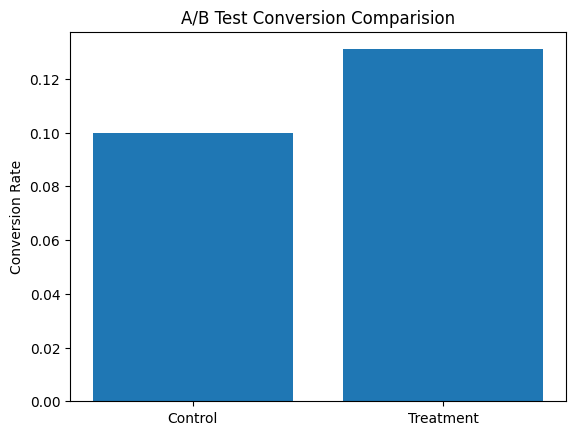

In [10]:
labels = ['Control', 'Treatment']
means = [control_mean, treatment_mean]

plt.bar(labels,means)
plt.ylabel('Conversion Rate')
plt.title('A/B Test Conversion Comparision')
plt.show()

In [ ]:
#95% confidence interval

z = stats.norm.ppf(0.975)  

control_ci_lower = control_mean - z * control_se
control_ci_upper = control_mean + z * control_se

treatment_ci_lower = treatment_mean - z * treatment_se 
treatment_ci_upper = treatment_mean + z * treatment_se

print("Control CI:", control_ci_lower, control_ci_upper)
print("Treatment CI:", treatment_ci_lower, treatment_ci_upper)

Control CI: 0.08140614903086316 0.11859385096913685
Treatment CI: 0.11008809356636755 0.15191190643363245


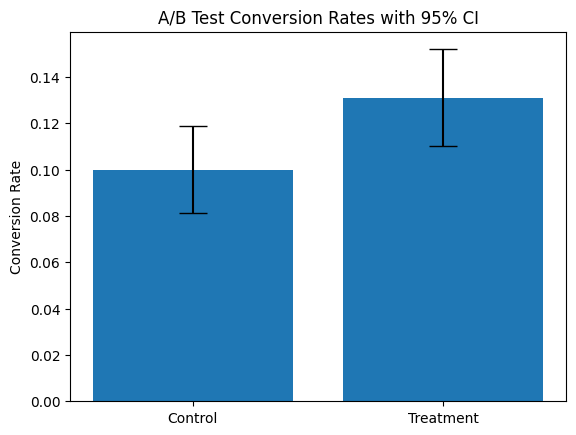

In [12]:
#visualize confidence intervals
labels = ['Control', 'Treatment']
means = [control_mean, treatment_mean]
errors = [control_se * 1.96, treatment_se * 1.96]

plt.bar(labels, means, yerr=errors, capsize=10)
plt.ylabel('Conversion Rate')
plt.title('A/B Test Conversion Rates with 95% CI')
plt.show()

In [14]:
def run_ab_test(control, treatment, alpha=0.05):
    n1 = len(control)
    n2 = len(treatment)

    mean1 = np.mean(control)
    mean2 = np.mean(treatment)

    std1 = np.std(control, ddof=1)
    std2 = np.std(treatment, ddof=1)

    se = np.sqrt((std1**2/n1) + (std2**2/n2))

    diff = mean2 - mean1

    t_stat = diff / se

    df = n1 + n2 - 2

    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df))

    decision = "Reject H0 (Significant Difference)" if p_value < alpha else "Fail to reject H0"

    return{
        "control_mean": mean1,
        "treatment_mean": mean2,
        "t_statistic": t_stat,
        "p_value": p_value,
        "decision": decision,
        "difference": diff
    }